In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def combine_results(folder, i):
    """
    Reads the three CSV files for a given folder and index, merges them on the 'index' column, and returns a combined DataFrame.
    """

    # Load both CSVs
    df_diver = pd.read_csv(f"results/{folder}/{i}/divergence_results.csv")
    df_agent = pd.read_csv(f"results/{folder}/{i}/agent_perf.csv")
    df_loss  = pd.read_csv(f"results/{folder}/{i}/train_loss.csv")

    # Make sure index column is treated as string or integer consistently
    df_diver["index"] = df_diver["index"].astype(str)
    df_agent["index"] = df_agent["index"].astype(str)
    df_loss["index"]  = df_loss["index"].astype(str)

    # Merge and keep only shared indices
    df_common = df_diver.merge(df_agent, on="index", how="inner")
    df_common = df_common.merge(df_loss, on="index", how="inner")

    return df_common

def extractor(folder, max_i):
    """
    Combine replicates of a given experiment type (folder) and compute mean, std, and sem across replicates for each column index.
    """
    dfs = [combine_results(folder=folder, i=i) for i in range(max_i)]
    for i, df in enumerate(dfs):
        df = df.copy()
        # Clean the index column
        df["index"] = pd.to_numeric(df["index"], errors="coerce")
        dfs[i] = df

    # Stack replicates along a new "replicate" axis
    panel = pd.concat(dfs, axis=0, keys=range(len(dfs)))

    mean_df = panel.groupby(level=1).mean()
    std_df  = panel.groupby(level=1).std()
    sem_df  = std_df/np.sqrt(max_i)

    return mean_df, std_df, sem_df

def count_num_replicates(folder):
    """
    Counts the number folders that contain the three required CSV files for a given experiment type (folder).
    """
    count = 0
    for i in range(100):  # Check up to 100 replicates
        diver_path = f"results/{folder}/{i}/divergence_results.csv"
        agent_path = f"results/{folder}/{i}/agent_perf.csv"
        loss_path  = f"results/{folder}/{i}/train_loss.csv"
        if os.path.exists(diver_path) and os.path.exists(agent_path) and os.path.exists(loss_path):
            count += 1
    return count


### Plot $\epsilon$-sufficiency and task success rate over training.

In [3]:
folders = {
    'final_4way/res_no_aux': {'line_label': 'No Auxiliary Losses', 'color': 'slategray', 'marker': 'v', 'linestyle': '--'},
    'final_4way/res_val_aux': {'line_label': 'Value Estimation', 'color': 'orange', 'marker': 'o', 'linestyle': '-'},
    'final_4way/res_pred_aux': {'line_label': 'Rollout Prediction', 'color': 'green', 'marker': 'o', 'linestyle': '-'},
    'final_4way/res_both_aux': {'line_label': 'Value + Rollout', 'color': 'blue', 'marker': 'o', 'linestyle': '-'},
}

<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3746293/2397860242.py:19: SyntaxWarning: invalid escape sequence '\e'
  axs[0].set_ylabel("$\epsilon$-Sufficiency Gap")


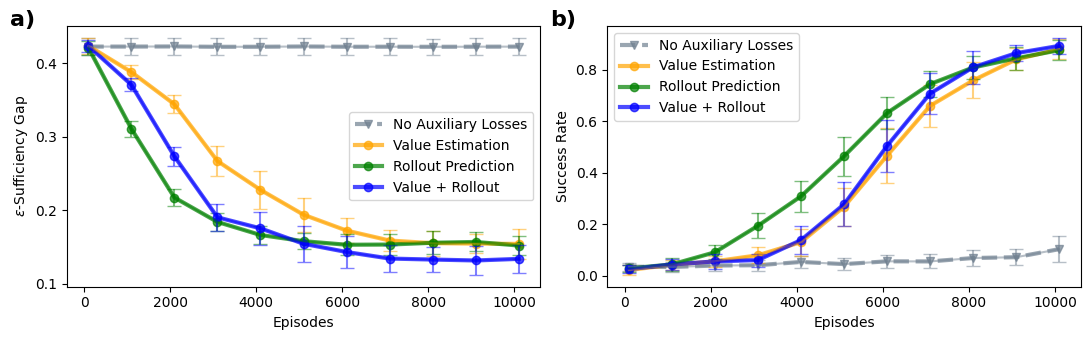

In [4]:
# Set up a two panel plot for TV and Success Rate

fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))

x = 'index'
y = 'tv_linear'

for fold, props in folders.items():

    mean_df, std_df, sem_df = extractor(fold, count_num_replicates(fold))

    axs[0].plot(mean_df[x], mean_df[y], c=props['color'], linewidth=3, label = props['line_label'], alpha=0.7, marker=props['marker'], linestyle=props['linestyle'])
    axs[0].errorbar(mean_df[x], mean_df[y],  std_df[y], color=props['color'], alpha=0.5, capsize = 5)


axs[0].set_xlabel("Episodes")
axs[0].set_xticks([0, 20, 40, 60, 80, 100])
axs[0].set_xticklabels([0, 2000, 4000, 6000, 8000, 10000])
axs[0].set_ylabel("$\epsilon$-Sufficiency Gap")
axs[0].set_yticks([0.1, 0.2, 0.3, 0.4])

x = 'index'
y = 'success_rate'

for fold, props in folders.items():

    mean_df, std_df, sem_df = extractor(fold, count_num_replicates(fold))

    axs[1].plot(mean_df[x], mean_df[y], c=props['color'], linewidth=3, label = props['line_label'], alpha=0.7, marker=props['marker'], linestyle=props['linestyle'])
    axs[1].errorbar(mean_df[x], mean_df[y],  std_df[y], color=props['color'], alpha=0.5, capsize = 5)


axs[1].set_xlabel("Episodes")
axs[1].set_xticks([0, 20, 40, 60, 80, 100])
axs[1].set_xticklabels([0, 2000, 4000, 6000, 8000, 10000])
axs[1].set_ylabel("Success Rate")

# Set up a) and b) labels on the top left of each subplot
axs[0].text(-0.12, 1.00, 'a)', transform=axs[0].transAxes, fontsize=16, fontweight='bold')
axs[1].text(-0.12, 1.00, 'b)', transform=axs[1].transAxes, fontsize=16, fontweight='bold')

axs[0].legend()
axs[1].legend()

fig.tight_layout()
plt.savefig("figures/combined_results.pdf")

### Plot $\epsilon$-sufficiency and task success rate

<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3746293/2717612753.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("$\epsilon$-Sufficiency Gap")


Processing folder: final_4way/res_no_aux
Processing folder: final_4way/res_val_aux
Processing folder: final_4way/res_pred_aux
Processing folder: final_4way/res_both_aux
Linear regression results: slope = -2.0803, intercept = 0.8826, r_value = -0.7771, p_value = 1.0238e-45, std_err = 0.1141


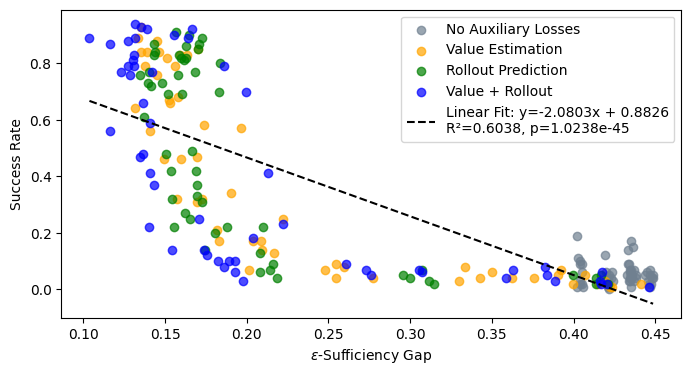

In [39]:
folders = {
    'final_4way/res_no_aux': {'line_label': 'No Auxiliary Losses', 'color': 'slategray', 'marker': 'v', 'linestyle': '--'},
    'final_4way/res_val_aux': {'line_label': 'Value Estimation', 'color': 'orange', 'marker': 'o', 'linestyle': '-'},
    'final_4way/res_pred_aux': {'line_label': 'Rollout Prediction', 'color': 'green', 'marker': 'o', 'linestyle': '-'},
    'final_4way/res_both_aux': {'line_label': 'Value + Rollout', 'color': 'blue', 'marker': 'o', 'linestyle': '-'},
}

x = 'tv_linear'
y = 'success_rate'

x_data = []
y_data = []

plt.figure(figsize=(8, 4))

for fold, props in folders.items():
    print(f"Processing folder: {fold}")
    for i in range(5):
        df_common = combine_results(folder=fold, i=i)
        if i == 0:
            plt.scatter(df_common[x], df_common[y], c=props['color'], alpha=0.7, label = props['line_label'])
        else:
            plt.scatter(df_common[x], df_common[y], c=props['color'], alpha=0.7)
        x_data.append(df_common[x])
        y_data.append(df_common[y])

# perform a linear regression on the combined data
from scipy.stats import linregress
x_combined = pd.concat(x_data)
y_combined = pd.concat(y_data)
slope, intercept, r_value, p_value, std_err = linregress(x_combined, y_combined)
print(f"Linear regression results: slope = {slope:.4f}, intercept = {intercept:.4f}, r_value = {r_value:.4f}, p_value = {p_value:.4e}, std_err = {std_err:.4f}")

# Plot the regression line
x_line = np.linspace(x_combined.min(), x_combined.max(), 100)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, color='black', linestyle='--', label=f'Linear Fit: y={slope:.4f}x + {intercept:.4f}\nR²={r_value**2:.4f}, p={p_value:.4e}')
plt.xlabel("$\epsilon$-Sufficiency Gap")
plt.ylabel("Success Rate")
plt.legend()
plt.savefig("figures/scatter_with_regression.pdf")

### T-test results

In [43]:
y = 'tv_linear'

mean_df, std_df, sem_df = extractor('final_4way/res_no_aux',25)
mean_1_end = mean_df[y].iloc[-1] 
std_1_end = std_df[y].iloc[-1]
mean_1_start = mean_df[y].iloc[0]
std_1_start = std_df[y].iloc[0]
print(mean_1_end, std_1_end, mean_1_start, std_1_start)

mean_df, std_df, sem_df = extractor('final_4way/res_val_aux',25)

mean_2_end = mean_df[y].iloc[-1]
std_2_end = std_df[y].iloc[-1]
mean_2_start = mean_df[y].iloc[0]
std_2_start = std_df[y].iloc[0]
print(mean_2_end, std_2_end, mean_2_start, std_2_start)

mean_df, std_df, sem_df = extractor('final_4way/res_pred_aux',25)

mean_3_end = mean_df[y].iloc[-1]
std_3_end = std_df[y].iloc[-1]
mean_3_start = mean_df[y].iloc[0]
std_3_start = std_df[y].iloc[0]
print(mean_3_end, std_3_end, mean_3_start, std_3_start)

mean_df, std_df, sem_df = extractor('final_4way/res_both_aux',20)

mean_4_end = mean_df[y].iloc[-1]
std_4_end = std_df[y].iloc[-1]
mean_4_start = mean_df[y].iloc[0]
std_4_start = std_df[y].iloc[0]
print(mean_4_end, std_4_end, mean_4_start, std_4_start)


# perform significance tests of the differences between all pairwise setups at the final chunk
# aussume normal distribution and use t-test
# collect pairwise results in a table, and print them
from scipy import stats
setups = [
    ("No Aux", mean_1_start, std_1_start, mean_1_end, std_1_end),
    ("Val Aux", mean_2_start, std_2_start, mean_2_end, std_2_end),
    ("Pred Aux", mean_3_start, std_3_start, mean_3_end, std_3_end),
    ("Both Aux", mean_4_start, std_4_start, mean_4_end, std_4_end),
]
for name, mean_i_start, std_i_start, mean_i_end, std_i_end in setups:
        # t-test
        t_stat, p_value = stats.ttest_ind_from_stats(
            mean1=mean_i_end, std1=std_i_end, nobs1=25,
            mean2=mean_i_start, std2=std_i_start, nobs2=25,
            equal_var=False
        )
        print(f"t-test between start and end for {name}: t-statistic = {t_stat:.4f}, p-value = {p_value:.12f}")

0.4223285984992981 0.011579519828270185 0.4223625564575195 0.01174873387992624
0.15420051574707028 0.019939500683011264 0.4234663438796997 0.010609104744762279
0.15199484884738917 0.013298263744993936 0.4209008061885834 0.009520978687135107
0.13308524377644057 0.015712543868849724 0.42382367253303527 0.008097127508894322
t-test between start and end for No Aux: t-statistic = -0.0103, p-value = 0.991830360597
t-test between start and end for Val Aux: t-statistic = -59.6085, p-value = 0.000000000000
t-test between start and end for Pred Aux: t-statistic = -82.2080, p-value = 0.000000000000
t-test between start and end for Both Aux: t-statistic = -82.2402, p-value = 0.000000000000


In [42]:
y = 'success_rate'

mean_df, std_df, sem_df = extractor('final_4way/res_no_aux',25)
mean_1_end = mean_df[y].iloc[-1] 
std_1_end = std_df[y].iloc[-1]
mean_1_start = mean_df[y].iloc[0]
std_1_start = std_df[y].iloc[0]
print(mean_1_end, std_1_end, mean_1_start, std_1_start)

mean_df, std_df, sem_df = extractor('final_4way/res_val_aux',25)

mean_2_end = mean_df[y].iloc[-1]
std_2_end = std_df[y].iloc[-1]
mean_2_start = mean_df[y].iloc[0]
std_2_start = std_df[y].iloc[0]
print(mean_2_end, std_2_end, mean_2_start, std_2_start)

mean_df, std_df, sem_df = extractor('final_4way/res_pred_aux',25)

mean_3_end = mean_df[y].iloc[-1]
std_3_end = std_df[y].iloc[-1]
mean_3_start = mean_df[y].iloc[0]
std_3_start = std_df[y].iloc[0]
print(mean_3_end, std_3_end, mean_3_start, std_3_start)

mean_df, std_df, sem_df = extractor('final_4way/res_both_aux',20)

mean_4_end = mean_df[y].iloc[-1]
std_4_end = std_df[y].iloc[-1]
mean_4_start = mean_df[y].iloc[0]
std_4_start = std_df[y].iloc[0]
print(mean_4_end, std_4_end, mean_4_start, std_4_start)


# perform significance tests of the differences between all pairwise setups at the final chunk
# aussume normal distribution and use t-test
# collect pairwise results in a table, and print them
from scipy import stats
setups = [
    ("No Aux", mean_1_start, std_1_start, mean_1_end, std_1_end),
    ("Val Aux", mean_2_start, std_2_start, mean_2_end, std_2_end),
    ("Pred Aux", mean_3_start, std_3_start, mean_3_end, std_3_end),
    ("Both Aux", mean_4_start, std_4_start, mean_4_end, std_4_end),
]
for name, mean_i_start, std_i_start, mean_i_end, std_i_end in setups:
        # t-test
        t_stat, p_value = stats.ttest_ind_from_stats(
            mean1=mean_i_end, std1=std_i_end, nobs1=25,
            mean2=mean_i_start, std2=std_i_start, nobs2=25,
            equal_var=False
        )
        print(f"t-test between start and end for {name}: t-statistic = {t_stat:.4f}, p-value = {p_value:.12f}")

0.10400000000000001 0.0501663898109747 0.036000000000000004 0.016072751268321594
0.8804000000000001 0.038131351929875254 0.022799999999999997 0.018601075237738275
0.8764 0.03795611501018867 0.0292 0.01255653880122491
0.8955 0.031199696354797753 0.025500000000000002 0.017614288458371995
t-test between start and end for No Aux: t-statistic = 6.4543, p-value = 0.000000471063
t-test between start and end for Val Aux: t-statistic = 101.0691, p-value = 0.000000000000
t-test between start and end for Pred Aux: t-statistic = 105.9552, p-value = 0.000000000000
t-test between start and end for Both Aux: t-statistic = 121.4116, p-value = 0.000000000000
